# 2026.07.01

# 데이터 전처리

In [7]:
import re
import pandas as pd

log_filepath = 'sample_logs.log'
output_csv_filepath = 'sample_logs.csv'

# 정규 표현식패턴 정의
log_pattern = re.compile(
    r'(?P<ip>\d+\.\d+\.\d+\.\d+)\s' # IP 주소
    r'- - \[(?P<datetime>[^\]]+)\] ' # 날짜 및 시간
    r'"(?P<method>GET|POST|PUT|DELETE|HEAD) ' # HTTP 메서드
    r'(?P<path>[^ ]+).*?"\s' # 요청 경로
    r'(?P<status>\d{3})\s' # 상태 코드
    r'(?P<size>\d+)' # 응답 크기
)

# 결과 저장
log_entries = []
with open(log_filepath, 'r') as f:
    for line in f:
        match = log_pattern.search(line)
        if match:
            entry = match.groupdict()
            # datetime을 datetime 객체로 변환
            entry['datetime'] = pd.to_datetime(entry['datetime'], format='%d/%b/%Y:%H:%M:%S %z')
            entry['status'] = int(entry['status'])
            entry['size'] = int(entry['size'])
            log_entries.append(entry)
# DataFrame 생성
df = pd.DataFrame(log_entries)
# 결과 확인
print(df.head())

               ip                  datetime method              path  status  \
0   172.29.117.82 2025-06-14 10:59:11+09:00    GET         /home.php     200   
1  10.248.203.131 2025-06-14 11:21:30+09:00    GET  /admin/login.php     403   
2  172.25.180.188 2025-06-14 11:55:08+09:00    GET  /admin/login.php     404   
3  172.22.253.123 2025-06-14 11:18:27+09:00    GET        /dashboard     403   
4  192.168.71.140 2025-06-14 10:38:19+09:00    GET  /admin/login.php     404   

   size  
0   189  
1  1024  
2  2048  
3   512  
4   512  


In [8]:
#path
log_filepath = 'sample_logs.log'
#csv파일로 저장
output_csv_filepath = 'parsed_logs.csv'

In [9]:
#정보 가져오기
log_pattern = re.compile(
    r'(?P<ip>\d+\.\d+\.\d+\.\d+)\s' # IP 주소
    r'- - \[(?P<datetime>[^\]]+)\] ' # 날짜 및 시간
    r'"(?P<method>GET|POST|PUT|DELETE|HEAD) ' # HTTP 메서드
    r'(?P<path>[^ ]+).*?"\s' # 요청 경로
    r'(?P<status>\d{3})\s' # 상태 코드
    r'(?P<size>\d+)' # 응답 크기
)

In [10]:
#결과 리스트
parsed_logs = []

#로그파일의 각 행의 문자열을 확인하고 정규식에 따라 결과 추출
with open(log_filepath, 'r') as f:
    for line in f:
        match = log_pattern.search(line)
        if match:
            parsed_logs.append(match.groupdict())

In [12]:
parsed_logs

[{'ip': '172.29.117.82',
  'datetime': '14/Jun/2025:10:59:11 +0900',
  'method': 'GET',
  'path': '/home.php',
  'status': '200',
  'size': '189'},
 {'ip': '10.248.203.131',
  'datetime': '14/Jun/2025:11:21:30 +0900',
  'method': 'GET',
  'path': '/admin/login.php',
  'status': '403',
  'size': '1024'},
 {'ip': '172.25.180.188',
  'datetime': '14/Jun/2025:11:55:08 +0900',
  'method': 'GET',
  'path': '/admin/login.php',
  'status': '404',
  'size': '2048'},
 {'ip': '172.22.253.123',
  'datetime': '14/Jun/2025:11:18:27 +0900',
  'method': 'GET',
  'path': '/dashboard',
  'status': '403',
  'size': '512'},
 {'ip': '192.168.71.140',
  'datetime': '14/Jun/2025:10:38:19 +0900',
  'method': 'GET',
  'path': '/admin/login.php',
  'status': '404',
  'size': '512'},
 {'ip': '10.128.66.93',
  'datetime': '14/Jun/2025:10:35:59 +0900',
  'method': 'GET',
  'path': '/home.php',
  'status': '404',
  'size': '1024'},
 {'ip': '192.168.75.62',
  'datetime': '14/Jun/2025:10:38:37 +0900',
  'method': 'GE

In [14]:
import csv

with open(output_csv_filepath, 'w', newline='') as csvfile:
    fieldnames = ['ip', 'datetime', 'method', 'path', 'status', 'size']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)

    #Write header
    writer.writeheader()
    for row in parsed_logs:
        writer.writerow(row)

    print('파일 저장 완료')

파일 저장 완료


In [15]:
#파일 로드
df = pd.read_csv(output_csv_filepath)

In [16]:
df

,ip,datetime,method,path,status,size
0,172.29.117.82,14/Jun/2025:10:59:11 +0900,GET,/home.php,200,189
1,10.248.203.131,14/Jun/2025:11:21:30 +0900,GET,/admin/login.php,403,1024
2,172.25.180.188,14/Jun/2025:11:55:08 +0900,GET,/admin/login.php,404,2048
3,172.22.253.123,14/Jun/2025:11:18:27 +0900,GET,/dashboard,403,512
4,192.168.71.140,14/Jun/2025:10:38:19 +0900,GET,/admin/login.php,404,512
...,...,...,...,...,...,...
495,172.21.22.154,14/Jun/2025:10:59:51 +0900,GET,/index.html,404,1024
496,192.168.145.66,14/Jun/2025:11:55:58 +0900,GET,/logout,404,1024
497,192.168.188.143,14/Jun/2025:11:42:06 +0900,GET,/dashboard,200,768
498,172.27.113.162,14/Jun/2025:10:02:40 +0900,POST,/submit,403,1024


In [17]:
df_403 = df[df['status'] == 403]
df_403

,ip,datetime,method,path,status,size
1,10.248.203.131,14/Jun/2025:11:21:30 +0900,GET,/admin/login.php,403,1024
3,172.22.253.123,14/Jun/2025:11:18:27 +0900,GET,/dashboard,403,512
10,192.168.133.95,14/Jun/2025:10:35:49 +0900,POST,/api/data,403,189
17,10.72.245.6,14/Jun/2025:11:09:56 +0900,GET,/dashboard,403,532
18,192.168.41.48,14/Jun/2025:11:37:38 +0900,POST,/api/data,403,189
...,...,...,...,...,...,...
469,172.29.118.196,14/Jun/2025:11:36:35 +0900,POST,/api/data,403,1024
478,10.170.116.238,14/Jun/2025:11:45:43 +0900,POST,/upload.php,403,512
482,10.223.64.6,14/Jun/2025:10:46:13 +0900,GET,/home.php,403,512
490,192.168.24.241,14/Jun/2025:10:30:29 +0900,GET,/home.php,403,2048


In [21]:
#path => /admin/...
acc_admin = df[df['path'].str.contains(r'^/admin')]
acc_admin.info()

<class 'pandas.DataFrame'>
Index: 62 entries, 1 to 494
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   ip        62 non-null     str  
 1   datetime  62 non-null     str  
 2   method    62 non-null     str  
 3   path      62 non-null     str  
 4   status    62 non-null     int64
 5   size      62 non-null     int64
dtypes: int64(2), str(4)
memory usage: 3.4 KB


In [25]:
#ip집계 => top5

top_5_ips = df.groupby('ip').size().reset_index(name='count').sort_values(by='count', ascending=True)
top_5_ips.head()

,ip,count
0,10.101.163.240,1
339,192.168.103.67,1
338,192.168.103.58,1
337,192.168.103.1,1
336,192.168.102.17,1


In [26]:
#데이터프레임 생성
data = {
    'Name': ['Alice', 'Bob', None],
    'Age': [25, None, 30],
    'Score': [85, 90, None]
}
df = pd.DataFrame(data)

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Name    2 non-null      str    
 1   Age     2 non-null      float64
 2   Score   2 non-null      float64
dtypes: float64(2), str(1)
memory usage: 204.0 bytes


In [29]:
df.isnull().sum()

Name     1
Age      1
Score    1
dtype: int64

In [31]:
df_missing_row = df.dropna()  # 결측치가 있는 행 제거
print(df_missing_row)

    Name   Age  Score
0  Alice  25.0   85.0


In [32]:
df_missing_cols = df.dropna(axis=1)
df_missing_cols

""
0
1
2


In [33]:
#결측치에 특정 값으로 대체
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Score'] = df['Score'].fillna(df['Score'].median())
df['Name'] = df['Name'].fillna(df['Name'].mode()[0])  # 최빈값으로 대체

df

,Name,Age,Score
0,Alice,25.0,85.0
1,Bob,27.5,90.0
2,Alice,30.0,87.5


# 이상치 처리

In [37]:
import numpy as np

#예제 데이터
data = {'Scores': [70, 75, 80, 85, 90, 150]}
df = pd.DataFrame(data)

In [43]:
Q1 = df['Scores'].quantile(0.25)
Q2 = df['Scores'].quantile(0.5)
Q3 = df['Scores'].quantile(0.75)
Q4 = df['Scores'].max()

IQR = Q3 - Q1
print(Q1)
print(Q3)
print(IQR)

76.25
88.75
12.5


In [41]:
low_ = Q1 - 1.5 * IQR
up_ = Q3 + 1.5 * IQR
print('up', up_)
print('low', low_)

up 107.5
low 57.5


In [44]:
df_result = df[(df['Scores'] < low_) | (df['Scores'] > up_)]
df_result

,Scores
5,150


In [45]:
df_result = df[(df['Scores'] >= low_) & (df['Scores'] <= up_)]
df_result

,Scores
0,70
1,75
2,80
3,85
4,90


In [46]:
df['Scores'] = df['Scores'].astype(float)
df.loc[df['Scores']<low_, 'Scores'] = low_
df.loc[df['Scores']>up_, 'Scores'] = up_

df

,Scores
0,70.0
1,75.0
2,80.0
3,85.0
4,90.0
5,107.5


In [47]:
#중복 데이터 확인 => 제거
# pandas 중복 데이터 확인 및 제거
import pandas as pd
# 예제 데이터
data = {
    'Name': ['Alice', 'Bob', 'Alice', 'Charlie', 'Bob'],
    'Age': [25, 30, 25, 35, 30],
    'Score': [85, 90, 85, 95, 90]
}
df = pd.DataFrame(data)
print('원본 데이터프레임 :')
print(df)

원본 데이터프레임 :
      Name  Age  Score
0    Alice   25     85
1      Bob   30     90
2    Alice   25     85
3  Charlie   35     95
4      Bob   30     90


In [52]:
print(df.duplicated())
print(df.duplicated().sum())
print(df.duplicated(subset=['Name']).sum())
print(df[df.duplicated()])

0    False
1    False
2     True
3    False
4     True
dtype: bool
2
2
    Name  Age  Score
2  Alice   25     85
4    Bob   30     90


In [ ]:
df_cleared = df.drop_duplicates()
df_cleared

,Name,Age,Score
0,Alice,25,85
1,Bob,30,90
3,Charlie,35,95


In [54]:
df_cleared1 = df.drop_duplicates(keep='last')
df_cleared1

,Name,Age,Score
2,Alice,25,85
3,Charlie,35,95
4,Bob,30,90


In [55]:
df_cleared2 = df.drop_duplicates(keep='last', subset=['Name'])
df_cleared2

,Name,Age,Score
2,Alice,25,85
3,Charlie,35,95
4,Bob,30,90


In [56]:
df_cleared3 = df.drop_duplicates(keep=False)
df_cleared3

,Name,Age,Score
3,Charlie,35,95


In [59]:
!pip install scikit-learn

  Using cached scikit_learn-1.9.0-cp312-cp312-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.22.1-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp312-cp312-macosx_12_0_arm64.whl (8.3 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached narwhals-2.22.1-py3-none-any.whl (454 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 13.2 MB/s  0:00:01 eta 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn] [scikit-learn]


   Original  Standardized  Normalized
0        50     -1.401826         0.0
1        80      0.215666         0.6
2        90      0.754829         0.8
3       100      1.293993         1.0
4        60     -0.862662         0.2


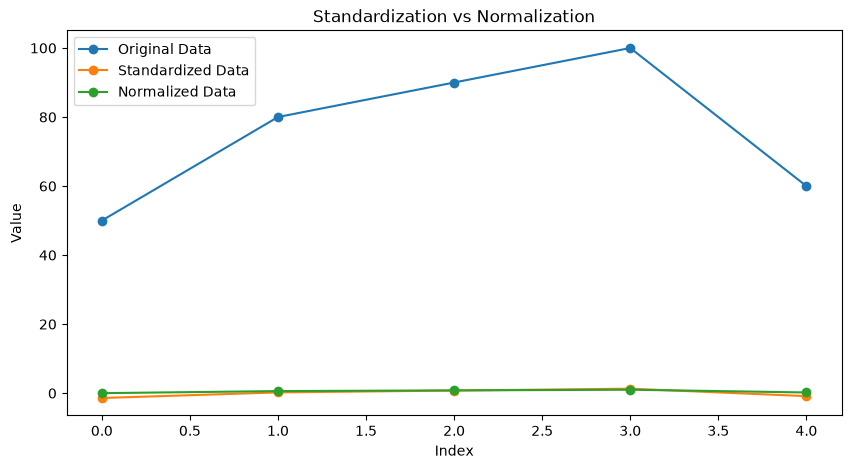

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
import matplotlib.pyplot as plt

# 데이터 생성
data = pd.DataFrame({'Original': [50, 80, 90, 100, 60]})

# 표준화
scaler_standard = StandardScaler()
data['Standardized'] = scaler_standard.fit_transform(data[['Original']])

# 정규화
scaler_minmax = MinMaxScaler()
data['Normalized'] = scaler_minmax.fit_transform(data[['Original']])

# 데이터 확인
print(data)

# 데이터 시각화
plt.figure(figsize=(10, 5))
plt.plot(data['Original'], label='Original Data', marker='o')
plt.plot(data['Standardized'], label='Standardized Data', marker='o')
plt.plot(data['Normalized'], label='Normalized Data', marker='o')
plt.legend()
plt.title('Standardization vs Normalization')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

In [62]:
data = pd.DataFrame({'Fruits': ['사과', '배', '포도', '사과', '포도']})


In [64]:
encoder1 = LabelEncoder()
data['Label Encoding'] = encoder1.fit_transform(data['Fruits'])
data

,Fruits,Label Encoding
0,사과,1
1,배,0
2,포도,2
3,사과,1
4,포도,2


In [65]:
#One-hot encoding
one_hot_encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = one_hot_encoder.fit_transform(data[['Label Encoding']])
one_hot_encoded

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [67]:
one_hot_columns = one_hot_encoder.get_feature_names_out()
one_hot_df = pd.DataFrame(one_hot_encoded, columns=one_hot_columns)

In [68]:
result_df = pd.concat([data, one_hot_df], axis=1)
result_df

,Fruits,Label Encoding,Label Encoding_0,Label Encoding_1,Label Encoding_2
0,사과,1,0.0,1.0,0.0
1,배,0,1.0,0.0,0.0
2,포도,2,0.0,0.0,1.0
3,사과,1,0.0,1.0,0.0
4,포도,2,0.0,0.0,1.0
